# Jackson 2.23: Potential in a Conducting Cube

This notebook works through Jackson Problem 2.23 for a hollow conducting cube:

- the four side walls are grounded,
- the top and bottom faces are both held at potential $V$,
- and there is no charge inside the cube.

The problem asks for:

1. the potential $\Phi(x,y,z)$ inside the cube,
2. the value at the center and how many terms are needed for three-significant-figure accuracy,
3. and the surface-charge density on the face $z=a$.

The derivation in the PDF is correct but a bit long. Here I keep the same result and write it in a cleaner separation-of-variables form, then check it numerically and visualize the solution.


## Boundary Conditions and Symmetry

Inside the cube there is no charge, so the potential satisfies Laplace's equation,

$$
\nabla^2\Phi = 0.
$$

The cube occupies

$$
0 < x < a,
\qquad
0 < y < a,
\qquad
0 < z < a,
$$

with boundary conditions

$$
\Phi(0,y,z)=\Phi(a,y,z)=0,
$$

$$
\Phi(x,0,z)=\Phi(x,a,z)=0,
$$

$$
\Phi(x,y,0)=\Phi(x,y,a)=V.
$$

Because the top and bottom are held at the same potential, the solution is symmetric about the midplane $z=a/2$. That symmetry makes the final expression much cleaner than carrying separate exponentials all the way through.


## Separation of Variables

Use a separated form

$$
\Phi(x,y,z)=X(x)Y(y)Z(z).
$$

The zero-potential walls at $x=0,a$ and $y=0,a$ force sine modes,

$$
X_n(x)=\sin\left(\frac{n\pi x}{a}\right),
\qquad
Y_m(y)=\sin\left(\frac{m\pi y}{a}\right),
$$

with $n,m=1,2,3,\dots$.

The corresponding $z$-equation is

$$
Z'' - \kappa_{nm}^2 Z = 0,
\qquad
\kappa_{nm} = \frac{\pi}{a}\sqrt{n^2+m^2}.
$$

Because the problem is symmetric under $z \mapsto a-z$, it is natural to choose the even solution about the midplane:

$$
Z_{nm}(z)=\cosh\left[\kappa_{nm}\left(z-\frac{a}{2}\right)\right].
$$

So the potential must have the form

$$
\Phi(x,y,z)=\sum_{n=1}^{\infty}\sum_{m=1}^{\infty}
C_{nm}
\sin\left(\frac{n\pi x}{a}\right)
\sin\left(\frac{m\pi y}{a}\right)
\cosh\left[\kappa_{nm}\left(z-\frac{a}{2}\right)\right].
$$

Now apply the boundary condition at $z=0$ or $z=a$:

$$
V=\sum_{n,m} C_{nm}
\sin\left(\frac{n\pi x}{a}\right)
\sin\left(\frac{m\pi y}{a}\right)
\cosh\left(\frac{\kappa_{nm}a}{2}\right).
$$

This means we need the double sine-series expansion of the constant function $V$ on the square. Orthogonality gives

$$
C_{nm}=
\frac{16V}{\pi^2 nm}
\frac{1}{\cosh\left(\frac{\pi}{2}\sqrt{n^2+m^2}\right)}
\qquad \text{for odd } n,m,
$$

and $C_{nm}=0$ if either index is even.

Therefore the final solution is

$$
\Phi(x,y,z)=
\sum_{n,m\;\text{odd}}
\frac{16V}{\pi^2 nm}
\sin\left(\frac{n\pi x}{a}\right)
\sin\left(\frac{m\pi y}{a}\right)
\frac{\cosh\left[\frac{\pi}{a}\sqrt{n^2+m^2}\left(z-\frac{a}{2}\right)\right]}{\cosh\left(\frac{\pi}{2}\sqrt{n^2+m^2}\right)}.
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.style.use("seaborn-v0_8-whitegrid")


In [3]:
a = 1.0
V = 1.0
eps0 = 1.0


def odd_indices(max_index):
    return range(1, max_index + 1, 2)


def cube_potential_series(x, y, z, a=1.0, V=1.0, n_max=21, m_max=21):
    x, y, z = np.broadcast_arrays(np.asarray(x, dtype=float), np.asarray(y, dtype=float), np.asarray(z, dtype=float))
    phi = np.zeros_like(x, dtype=float)
    for n in odd_indices(n_max):
        sin_x = np.sin(n * np.pi * x / a)
        for m in odd_indices(m_max):
            sin_y = np.sin(m * np.pi * y / a)
            s = np.sqrt(n**2 + m**2)
            coeff = 16.0 * V / (np.pi**2 * n * m * np.cosh(0.5 * np.pi * s))
            phi += coeff * sin_x * sin_y * np.cosh(np.pi * s * (z / a - 0.5))
    return phi


def cube_surface_charge_top(x, y, a=1.0, V=1.0, eps0=1.0, n_max=21, m_max=21):
    x, y = np.broadcast_arrays(np.asarray(x, dtype=float), np.asarray(y, dtype=float))
    sigma = np.zeros_like(x, dtype=float)
    for n in odd_indices(n_max):
        sin_x = np.sin(n * np.pi * x / a)
        for m in odd_indices(m_max):
            sin_y = np.sin(m * np.pi * y / a)
            s = np.sqrt(n**2 + m**2)
            sigma += (
                16.0 * eps0 * V / (np.pi * a)
                * (s / (n * m))
                * np.tanh(0.5 * np.pi * s)
                * sin_x * sin_y
            )
    return sigma


def center_terms(max_index=15, V=1.0):
    terms = []
    for n in odd_indices(max_index):
        for m in odd_indices(max_index):
            value = (
                16.0 * V / (np.pi**2 * n * m)
                * np.sin(n * np.pi / 2.0)
                * np.sin(m * np.pi / 2.0)
                / np.cosh(0.5 * np.pi * np.sqrt(n**2 + m**2))
            )
            terms.append((n, m, value, n**2 + m**2))
    terms.sort(key=lambda item: (item[3], item[0], item[1]))
    return terms


## Potential Slices Inside the Cube

The interior is highest along the midplane and drops to zero along the four grounded side walls. Because the top and bottom are both fixed at the same value, the field pattern is symmetric about $z=a/2$.


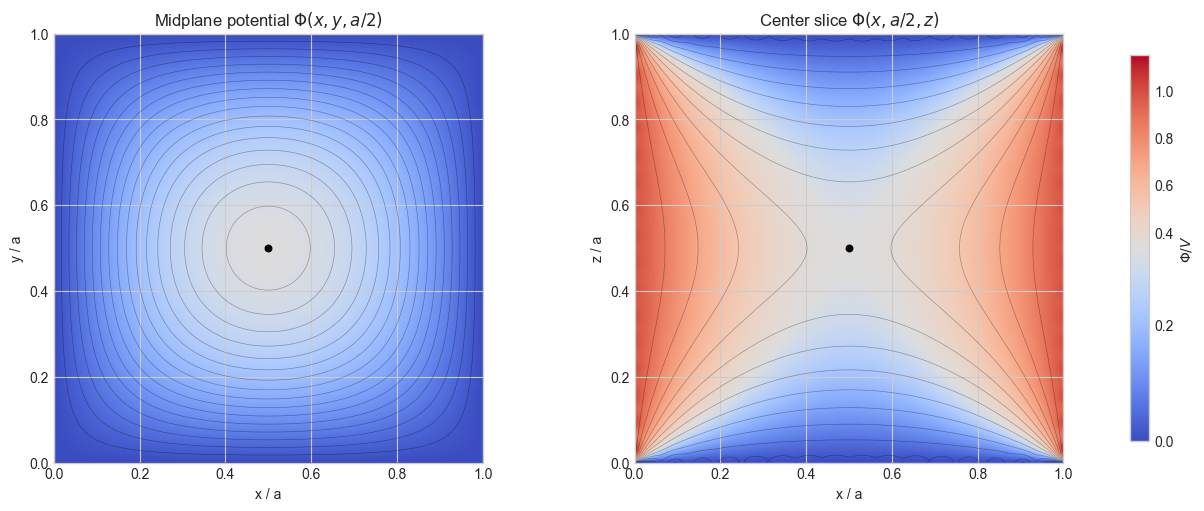

In [4]:
grid = np.linspace(0.0, a, 240)
X, Y = np.meshgrid(grid, grid, indexing='xy')
xy_mid = cube_potential_series(X, Y, 0.5 * a, a=a, V=V, n_max=31, m_max=31)
xz_mid = cube_potential_series(X, 0.5 * a, Y, a=a, V=V, n_max=31, m_max=31)

vmax = max(np.max(np.abs(xy_mid)), np.max(np.abs(xz_mid)))
norm = TwoSlopeNorm(vmin=0.0, vcenter=V/3.0, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.0), constrained_layout=True)

im0 = axes[0].imshow(xy_mid.T, origin='lower', extent=(0, 1, 0, 1), cmap='coolwarm', norm=norm)
axes[0].contour(X, Y, xy_mid, levels=16, colors='black', linewidths=0.45, alpha=0.35)
axes[0].scatter([0.5], [0.5], color='black', s=22)
axes[0].set_title(r'Midplane potential $\Phi(x,y,a/2)$')
axes[0].set_xlabel('x / a')
axes[0].set_ylabel('y / a')

im1 = axes[1].imshow(xz_mid.T, origin='lower', extent=(0, 1, 0, 1), cmap='coolwarm', norm=norm)
axes[1].contour(X, Y, xz_mid, levels=16, colors='black', linewidths=0.45, alpha=0.35)
axes[1].scatter([0.5], [0.5], color='black', s=22)
axes[1].set_title(r'Center slice $\Phi(x,a/2,z)$')
axes[1].set_xlabel('x / a')
axes[1].set_ylabel('z / a')

fig.colorbar(im1, ax=axes, shrink=0.9, label=r'$\Phi/V$')
plt.show()


## Center Value and Convergence

At the center $x=y=z=a/2$, the series simplifies to

$$
\Phi\left(\frac{a}{2},\frac{a}{2},\frac{a}{2}\right)=
\sum_{n,m\;\text{odd}}
\frac{16V}{\pi^2 nm}
\frac{\sin(n\pi/2)\sin(m\pi/2)}{\cosh\left(\frac{\pi}{2}\sqrt{n^2+m^2}\right)}.
$$

The first few nonzero contributions are exactly the pattern quoted in the PDF:

$$
0.3475V,
\quad -0.00752V,
\quad -0.00752V,
\quad +0.000460V, \dots
$$

This is why only a few terms are needed to reach three-significant-figure accuracy. There is one small nuance worth stating explicitly: if one uses the rounded four-decimal contributions printed in the PDF, the third partial sum already looks like $0.333V$. With exact arithmetic, the fourth nonzero term is what makes the three-significant-figure agreement unambiguous.


In [5]:
from decimal import Decimal, ROUND_HALF_UP

def round_half_up(value, decimals):
    quantum = Decimal('1').scaleb(-decimals)
    return float(Decimal(str(value)).quantize(quantum, rounding=ROUND_HALF_UP))

terms = center_terms(max_index=21, V=V)
term_values = np.array([term[2] for term in terms])
partial_sums = np.cumsum(term_values)
rounded_terms_pdf = np.array([round_half_up(val, 4) for val in term_values])
partial_sums_pdf_style = np.cumsum(rounded_terms_pdf)
target = V / 3.0
errors = np.abs(partial_sums - target)
first_three_sig_exact = np.argmax(errors < 5e-4) + 1
target_pdf = round_half_up(target, 3)
first_pdf_style = np.argmax([round_half_up(val, 3) == target_pdf for val in partial_sums_pdf_style]) + 1

print('First eight nonzero center contributions:')
for k, (n, m, value, _) in enumerate(terms[:8], start=1):
    print(f'{k:2d}: (n,m)=({n},{m}) contribution = {value:+.6f}')

print()
print(f'Exact average from Problem 2.28: V/3 = {target:.12f}')
print(f'Center value from 41x41 odd-mode truncation: {cube_potential_series(0.5*a, 0.5*a, 0.5*a, a=a, V=V, n_max=41, m_max=41):.12f}')
print(f'Number of terms if each contribution is rounded as in the PDF: {first_pdf_style}')
print(f'Number of nonzero terms needed for strict 3-significant-figure agreement: {first_three_sig_exact}')


First eight nonzero center contributions:
 1: (n,m)=(1,1) contribution = +0.347546
 2: (n,m)=(1,3) contribution = -0.007524
 3: (n,m)=(3,1) contribution = -0.007524
 4: (n,m)=(3,3) contribution = +0.000460
 5: (n,m)=(1,5) contribution = +0.000215
 6: (n,m)=(5,1) contribution = +0.000215
 7: (n,m)=(3,5) contribution = -0.000023
 8: (n,m)=(5,3) contribution = -0.000023

Exact average from Problem 2.28: V/3 = 0.333333333333
Center value from 41x41 odd-mode truncation: 0.333333333333
Number of terms if each contribution is rounded as in the PDF: 4
Number of nonzero terms needed for strict 3-significant-figure agreement: 4


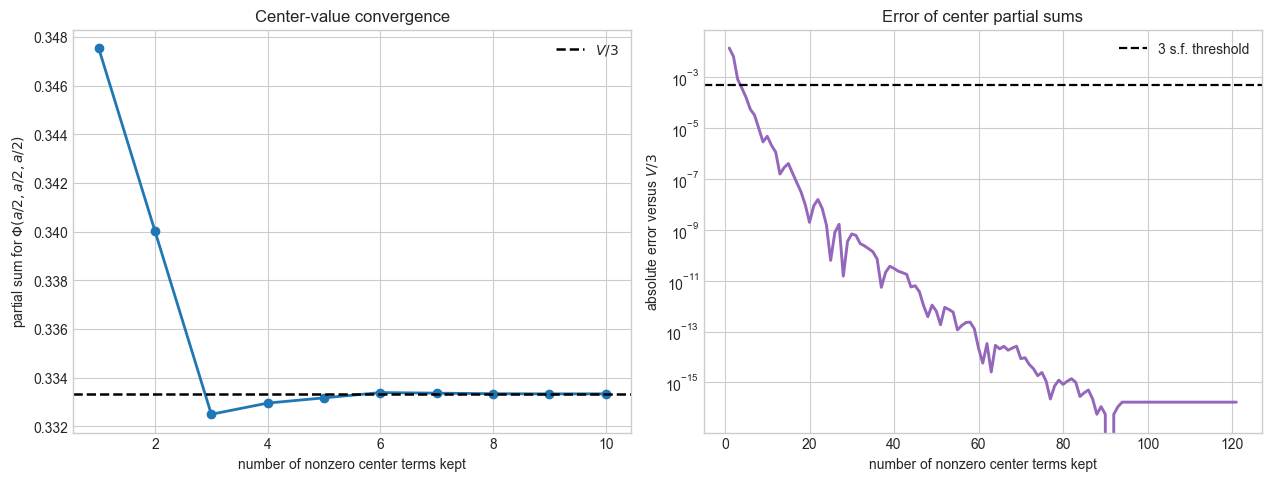

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.7), constrained_layout=True)

axes[0].plot(np.arange(1, 11), partial_sums[:10], marker='o', lw=2.0)
axes[0].axhline(target, color='black', ls='--', lw=1.8, label=r'$V/3$')
axes[0].set_xlabel('number of nonzero center terms kept')
axes[0].set_ylabel(r'partial sum for $\Phi(a/2,a/2,a/2)$')
axes[0].set_title('Center-value convergence')
axes[0].legend()

axes[1].semilogy(np.arange(1, len(errors) + 1), errors, color='tab:purple', lw=2.1)
axes[1].axhline(5e-4, color='black', ls='--', lw=1.6, label='3 s.f. threshold')
axes[1].set_xlabel('number of nonzero center terms kept')
axes[1].set_ylabel('absolute error versus $V/3$')
axes[1].set_title('Error of center partial sums')
axes[1].legend()

plt.show()


## Connection to Problem 2.28

The cube has six faces, and two of them are at potential $V$ while the other four are at zero. Therefore the arithmetic average of the face potentials is

$$
\Phi_{\rm avg,faces}=\frac{2V+4\cdot 0}{6}=\frac{V}{3}.
$$

So Jackson 2.28 predicts immediately that the center value here must be $V/3$. The separation-of-variables series above converges to exactly the same value, providing a strong consistency check.


## Surface Charge Density on the Top Face

The interior surface-charge density on the top conductor $z=a$ is obtained from the normal derivative:

$$
\sigma = \varepsilon_0\left.\frac{\partial \Phi}{\partial z}\right|_{z=a},
$$

because the inward normal to the interior surface points in the negative-$z$ direction.

Differentiating the series gives

$$
\sigma(x,y)=
\frac{16\varepsilon_0V}{\pi a}
\sum_{n,m\;\text{odd}}
\frac{\sqrt{n^2+m^2}}{nm}
\sin\left(\frac{n\pi x}{a}\right)
\sin\left(\frac{m\pi y}{a}\right)
\tanh\left(\frac{\pi}{2}\sqrt{n^2+m^2}\right).
$$

This charge density becomes strongly enhanced near the edges because the grounded side walls force the tangential field to turn sharply there.


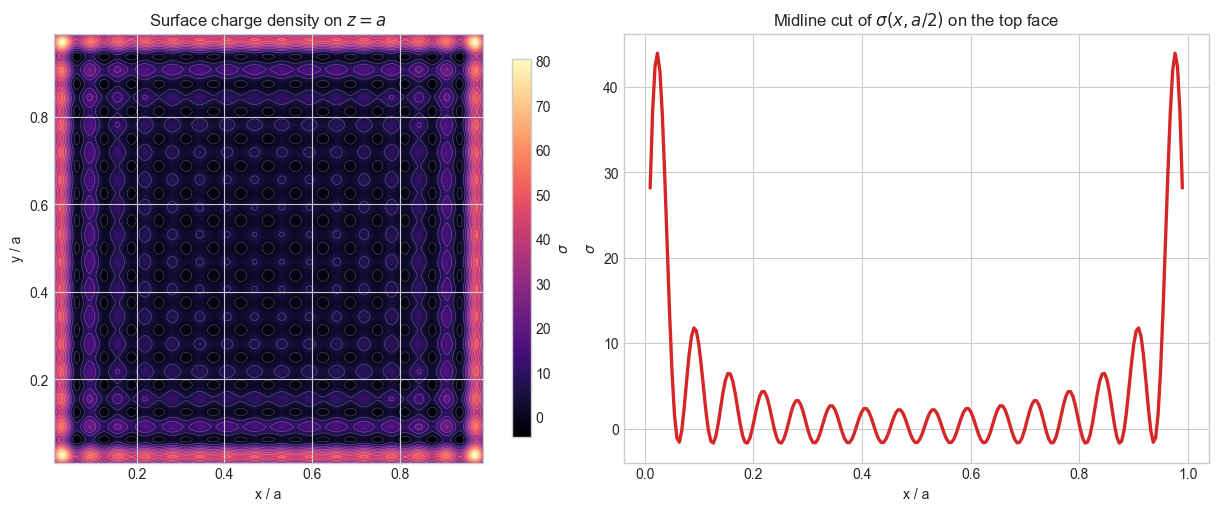

In [7]:
edge_cut = np.linspace(0.01, 0.99, 220)
Xc, Yc = np.meshgrid(edge_cut, edge_cut, indexing='xy')
sigma_top = cube_surface_charge_top(Xc, Yc, a=a, V=V, eps0=eps0, n_max=31, m_max=31)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0), constrained_layout=True)

im = axes[0].imshow(sigma_top.T, origin='lower', extent=(0.01, 0.99, 0.01, 0.99), cmap='magma')
axes[0].contour(Xc, Yc, sigma_top, levels=14, colors='white', linewidths=0.35, alpha=0.35)
axes[0].set_title(r'Surface charge density on $z=a$')
axes[0].set_xlabel('x / a')
axes[0].set_ylabel('y / a')
fig.colorbar(im, ax=axes[0], shrink=0.88, label=r'$\sigma$')

midline = cube_surface_charge_top(edge_cut, 0.5 * a, a=a, V=V, eps0=eps0, n_max=31, m_max=31)
axes[1].plot(edge_cut, midline, lw=2.4, color='tab:red')
axes[1].set_title(r'Midline cut of $\sigma(x,a/2)$ on the top face')
axes[1].set_xlabel('x / a')
axes[1].set_ylabel(r'$\sigma$')

plt.show()


## Takeaway

Jackson 2.23 is a clean separation-of-variables problem whose result is richer than it first looks:

- the potential is a double sine series in $x$ and $y$,
- the $z$ dependence is hyperbolic because the top and bottom planes are held at equal potential,
- the center value converges rapidly to $V/3$,
- and that $V/3$ is exactly what Problem 2.28 predicts from the average of the face potentials.

So the series solution, the numerical center evaluation, and the symmetry theorem all point to the same answer.
